# 💬 Natural Language Processing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SharifiZarchi/IntroAI/blob/main/Session_09/NLP/NLP_Tutorial_EN.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2FSharifiZarchi%2FIntroAI%2Fblob%2Fmain%2FSession_09%2FNLP%2FNLP_Tutorial_EN.ipynb)

Images were numbers from the start. Words are not. This session covers the two ideas that fixed that, and then puts them to work:

1. One-hot: the obvious representation, and why it fails
2. Word embeddings: meaning as coordinates, with pretrained vectors
3. The transformer layer, implemented from scratch
4. Using a real pretrained transformer
5. A Kaggle competition, end to end
6. Summary and next steps

Prerequisites: the sigmoid neuron, softmax and cross-entropy, and the training loop (Sessions 7 and 8). **On Colab** everything is preinstalled and no GPU is required. Parts 4 and 5 download pretrained models (about 700 MB once); the fine-tuning cell in Part 5 takes about four minutes on a CPU and under a minute on a Colab GPU.

**How to run:** click a cell and press `Shift + Enter`, in order, top to bottom. Every part ends with exercises whose solutions are one click away.

---
# Part 1: One-hot, and why it fails

A model needs numbers. The direct translation gives each word in the vocabulary its own column, so a word becomes a vector of zeros with a single 1. That is a **one-hot** vector:

In [1]:
import numpy as np

vocabulary = ["cat", "dog", "window", "run"]
one_hot = np.eye(len(vocabulary))

for word, vector in zip(vocabulary, one_hot):
    print(f"{word:8s} {vector}")

cat      [1. 0. 0. 0.]
dog      [0. 1. 0. 0.]
window   [0. 0. 1. 0.]
run      [0. 0. 0. 1.]


Two defects follow immediately, and both are fatal at real scale.

**Dimension.** A realistic vocabulary holds tens of thousands of words, so every word becomes a vector of tens of thousands of numbers with exactly one non-zero entry.

**No similarity.** Each word owns a separate column, so every pair of distinct words sits at the same distance. The representation cannot express that a cat is more like a dog than like a window:

In [2]:
for i in range(len(vocabulary)):
    for j in range(i + 1, len(vocabulary)):
        distance = np.linalg.norm(one_hot[i] - one_hot[j])
        print(f"distance({vocabulary[i]:7s}, {vocabulary[j]:7s}) = {distance:.3f}")

distance(cat    , dog    ) = 1.414
distance(cat    , window ) = 1.414
distance(cat    , run    ) = 1.414
distance(dog    , window ) = 1.414
distance(dog    , run    ) = 1.414
distance(window , run    ) = 1.414


Every distance is the same number. What we want instead is a **short, dense** vector per word, positioned so that similar meanings sit close together. The standard way to compare such vectors is **cosine similarity**, the dot product of the normalized vectors:

$$\cos(a, b) = \frac{a \cdot b}{\|a\| \, \|b\|}$$

It is +1 for identical directions, 0 for unrelated, and negative for opposite. With two-dimensional vectors chosen by hand, the difference from one-hot is immediate:

cos(cat, dog)    = 0.96
cos(cat, window) = 0.14


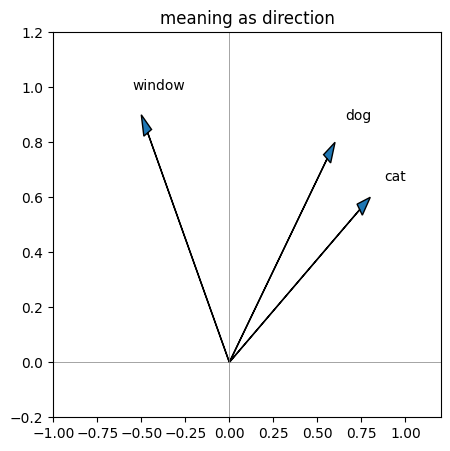

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

demo_vectors = {"cat": np.array([0.8, 0.6]), "dog": np.array([0.6, 0.8]), "window": np.array([-0.5, 0.9])}

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

print("cos(cat, dog)    =", round(cosine(demo_vectors["cat"], demo_vectors["dog"]), 2))
print("cos(cat, window) =", round(cosine(demo_vectors["cat"], demo_vectors["window"]), 2))

plt.figure(figsize=(5, 5))
for name, v in demo_vectors.items():
    plt.arrow(0, 0, v[0], v[1], head_width=0.05, length_includes_head=True)
    plt.text(v[0] * 1.1, v[1] * 1.1, name)
plt.xlim(-1, 1.2); plt.ylim(-0.2, 1.2)
plt.axhline(0, color="gray", linewidth=0.5); plt.axvline(0, color="gray", linewidth=0.5)
plt.title("meaning as direction")
plt.show()

`cat` and `dog` point almost the same way (0.96) while `window` points elsewhere (0.14). Nobody writes these coordinates by hand in a real system. Part 2 uses vectors learned from billions of words.

### ✏️ Exercise 1
A realistic English vocabulary has about 50,000 words. If every word is a one-hot vector of 32-bit floats, how much memory does a single **sentence of 20 words** take? Compute it, then compare with the 50-dimensional vectors of Part 2.

In [4]:
# ✏️ your calculation



<details>
<summary>💡 Solution (click to open)</summary>

```python
vocab_size, sentence_length, bytes_per_float = 50_000, 20, 4
one_hot_bytes = vocab_size * sentence_length * bytes_per_float
dense_bytes = 50 * sentence_length * bytes_per_float
print(f"one-hot: {one_hot_bytes / 1e6:.1f} MB per sentence")
print(f"dense 50-dim: {dense_bytes / 1e3:.1f} kB per sentence")
print("ratio:", one_hot_bytes // dense_bytes)
```

Four megabytes for one sentence against four kilobytes, a factor of a thousand, and the one-hot version carries no similarity information at all. Dense vectors are both smaller and more informative, which is why nothing modern uses one-hot for words.

</details>

### ✏️ Exercise 2
Verify the "all distances are equal" claim for a larger vocabulary: build one-hot vectors for 100 words with `np.eye(100)` and check that every pairwise distance equals the same value. What is that value, and why?

In [5]:
# ✏️ your check



<details>
<summary>💡 Solution (click to open)</summary>

```python
big = np.eye(100)
distances = [np.linalg.norm(big[i] - big[j]) for i in range(100) for j in range(i + 1, 100)]
print("unique distances:", set(np.round(distances, 6)))
print("sqrt(2) =", round(float(np.sqrt(2)), 6))
```

Every distance is the square root of 2, because two different one-hot vectors differ in exactly two coordinates, each by 1. The geometry is the same no matter which words are compared, so no notion of meaning can be read out of it.

</details>

---
# Part 2: Word embeddings

An **embedding** gives each word a dense vector of a few dozen numbers, learned so that words appearing in similar contexts get similar vectors. The training task behind word2vec and GloVe needs no human labels: predict a word from its neighbors, or the neighbors from the word, over a large corpus. Words that are interchangeable in context are pushed together.

Training that on billions of words takes hours, so we do what practitioners do and load vectors that are already trained. The file below holds the 20,000 most frequent English words as 50-dimensional GloVe vectors, trained on Wikipedia and news text:

In [6]:
import os
from urllib.request import urlretrieve

BASE_URL = "https://raw.githubusercontent.com/SharifiZarchi/IntroAI/main/Session_09/NLP/"

if not os.path.exists("glove_subset.npz"):
    urlretrieve(BASE_URL + "glove_subset.npz", "glove_subset.npz")

data = np.load("glove_subset.npz")
words = [str(w) for w in data["words"]]
vectors = data["vectors"]
word_to_id = {w: i for i, w in enumerate(words)}

normed = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
print("vocabulary:", len(words), "words | dimensions:", vectors.shape[1])
print("vector for 'cat':", np.round(vectors[word_to_id["cat"]][:8], 2), "...")

vocabulary: 20000 words | dimensions: 50
vector for 'cat': [ 0.45 -0.5  -0.54 -0.02  0.22  0.55 -0.67 -0.69] ...


Fifty numbers per word, and every one of them was learned from raw text. Nearest neighbours by cosine similarity show what those numbers encode:

In [7]:
def neighbors(word, k=6):
    similarity = normed @ normed[word_to_id[word]]
    best = similarity.argsort()[::-1][1:k + 1]
    return [words[i] for i in best]

for word in ["cat", "king", "paris", "swim"]:
    print(f"{word:8s} -> {neighbors(word)}")

cat      -> ['dog', 'rabbit', 'monkey', 'rat', 'cats', 'snake']
king     -> ['prince', 'queen', 'ii', 'emperor', 'son', 'uncle']
paris    -> ['france', 'brussels', 'amsterdam', 'french', 'vienna', 'london']
swim     -> ['swimming', 'swam', 'surfing', 'swimmers', 'diving', 'jumping']


Nobody labeled any of this. `cat` sits next to dog, rabbit and monkey; `paris` next to other capitals. Co-occurrence in text was enough.

### 2.1 Arithmetic with words
If direction carries meaning, directions can be added and subtracted. The famous example is `king - man + woman`:

In [8]:
def analogy(a, b, c, k=3):
    target = normed[word_to_id[b]] - normed[word_to_id[a]] + normed[word_to_id[c]]
    target = target / np.linalg.norm(target)
    order = (normed @ target).argsort()[::-1]
    return [words[i] for i in order if words[i] not in (a, b, c)][:k]

print("man : king    :: woman :", analogy("man", "king", "woman"))
print("france : paris :: iran :", analogy("france", "paris", "iran"))
print("small : smaller :: big :", analogy("small", "smaller", "big"))

man : king    :: woman : ['queen', 'throne', 'prince']
france : paris :: iran : ['tehran', 'iranian', 'cairo']
small : smaller :: big : ['bigger', 'competitors', 'lose']


The vector arithmetic lands on `queen`, on `tehran`, and on `bigger`. Gender, capital-of, and comparative-degree are directions in this space that nobody programmed; they fell out of the training objective.

### 2.2 Seeing the space
Fifty dimensions cannot be drawn, but PCA (a standard projection) compresses them to two while keeping the largest variation. Four groups of words, coloured by group:

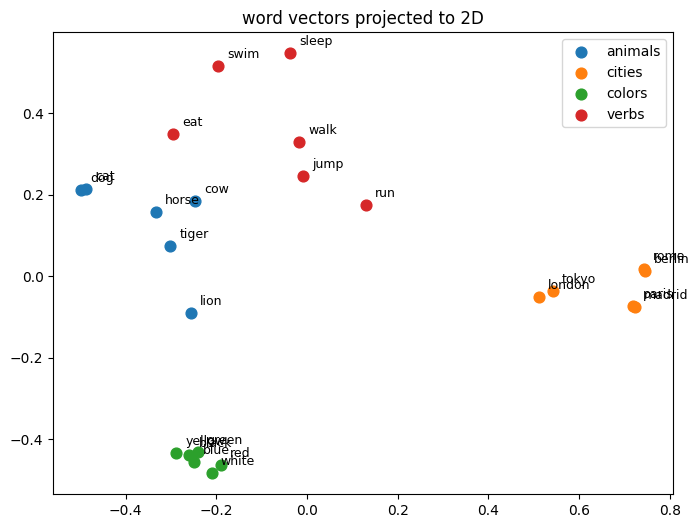

In [9]:
from sklearn.decomposition import PCA

groups = {
    "animals": ["cat", "dog", "horse", "cow", "lion", "tiger"],
    "cities": ["paris", "london", "tokyo", "berlin", "madrid", "rome"],
    "colors": ["red", "blue", "green", "yellow", "black", "white"],
    "verbs": ["run", "walk", "jump", "swim", "eat", "sleep"],
}

selected = [w for group in groups.values() for w in group]
points = PCA(n_components=2, random_state=0).fit_transform(normed[[word_to_id[w] for w in selected]])

plt.figure(figsize=(8, 6))
start = 0
for name, group in groups.items():
    chunk = points[start:start + len(group)]
    plt.scatter(chunk[:, 0], chunk[:, 1], label=name, s=60)
    for (x, y), word in zip(chunk, group):
        plt.text(x + 0.02, y + 0.02, word, fontsize=9)
    start += len(group)
plt.legend(); plt.title("word vectors projected to 2D")
plt.show()

The groups separate without ever being told that a category exists. The same structure is visible as numbers in a similarity matrix:

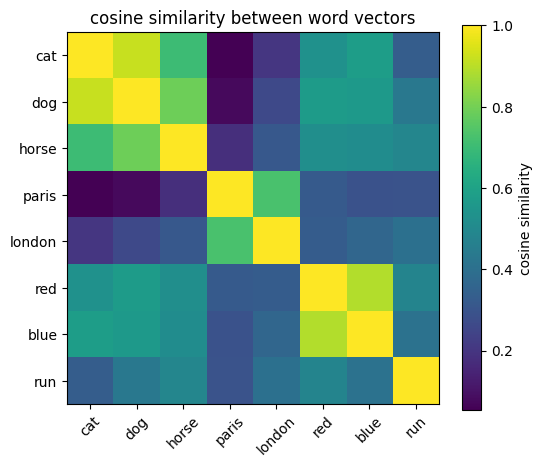

In [10]:
probes = ["cat", "dog", "horse", "paris", "london", "red", "blue", "run"]
P = normed[[word_to_id[w] for w in probes]]

plt.figure(figsize=(6, 5))
plt.imshow(P @ P.T, cmap="viridis")
plt.colorbar(label="cosine similarity")
plt.xticks(range(len(probes)), probes, rotation=45); plt.yticks(range(len(probes)), probes)
plt.title("cosine similarity between word vectors")
plt.show()

### 2.3 The limit of these vectors
Each word owns exactly **one** row of the table, so a word with several meanings gets a single averaged vector. `bank` is a river edge and a financial institution, and its neighbours show the collision:

In [11]:
print("bank ->", neighbors("bank", 8))

bank -> ['banks', 'securities', 'banking', 'investment', 'exchange', 'financial', 'credit', 'lender']


The list mixes finance words with nothing from the river sense: the dominant meaning in the training corpus wins, and the other one is smeared away. No table with one row per word can do better, because the table never sees the sentence. Fixing that requires a representation computed **per sentence**, which is what Parts 3 and 4 build.

### ✏️ Exercise 3
Print the neighbours of `king`, `computer` and `music`, then find a word whose neighbours look wrong or surprising, and explain what the corpus probably contained.

In [12]:
# ✏️ your probes



<details>
<summary>💡 Solution (click to open)</summary>

```python
for word in ["king", "computer", "music", "apple"]:
    print(f"{word:9s} -> {neighbors(word)}")
```

`apple` is the instructive case: its neighbours are technology brands rather than fruit, because Wikipedia and news text discuss the company far more often than the fruit. Embeddings mirror the corpus, not the dictionary, and the same effect appears with names, professions and any word carrying social bias, which is the Session 1 warning in vector form.

</details>

### ✏️ Exercise 4
Build two analogies of your own with `analogy(a, b, c)`, one that works and one that fails. Suggestions to start from: `paris : france :: tokyo : ?` and `walking : walked :: swimming : ?`

In [13]:
# ✏️ your analogies



<details>
<summary>💡 Solution (click to open)</summary>

```python
print("paris : france :: tokyo :", analogy("paris", "france", "tokyo"))
print("walking : walked :: swimming :", analogy("walking", "walked", "swimming"))
```

The country analogy works (`japan`), the verb-tense one does not: it returns sports words, because in a 50-dimensional space trained on news, `swimming` sits closer to olympics than to its own past tense. Analogies are a real property of the space but not a reliable one, especially with small vectors and rare word forms.

</details>

### ✏️ Exercise 5
Use the vectors to solve an odd-one-out puzzle: given `["cat", "dog", "horse", "paris"]`, compute the average vector of the group and report the word with the lowest cosine similarity to it. Does the method also work for `["red", "blue", "green", "run"]`?

In [14]:
# ✏️ odd one out



<details>
<summary>💡 Solution (click to open)</summary>

```python
def odd_one_out(group):
    matrix = normed[[word_to_id[w] for w in group]]
    center = matrix.mean(axis=0)
    center = center / np.linalg.norm(center)
    scores = matrix @ center
    return group[int(scores.argmin())]

print(odd_one_out(["cat", "dog", "horse", "paris"]))
print(odd_one_out(["red", "blue", "green", "run"]))
```

Both puzzles are solved correctly. This is the whole trick behind semantic search and recommendation by content: represent items as vectors, then measure angles. Nothing more complicated is required.

</details>

---
# Part 3: The transformer layer, implemented

A word vector that ignores the sentence cannot resolve `bank`. **Attention** fixes that by letting every token look at every other token and take a weighted average of what it finds, with the weights computed from the content itself.

Each token produces three vectors through three learnable matrices:

- **Query** $Q$: what am I looking for?
- **Key** $K$: what do I offer?
- **Value** $V$: what do I pass on when selected?

The score of token $i$ attending to token $j$ is the dot product of $Q_i$ and $K_j$. Softmax turns the scores of one token into weights that sum to 1, and the output is the weighted sum of the values:

$$\text{scores} = \frac{Q K^{\top}}{\sqrt{d}}, \qquad \text{weights} = \text{softmax}(\text{scores}), \qquad \text{output} = \text{weights} \cdot V$$

The whole mechanism is nine lines of PyTorch:

In [15]:
import torch

def attention(X, Wq, Wk, Wv, mask=None):
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    d = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / d ** 0.5
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

print("attention implemented ✅")

attention implemented ✅


In [16]:
torch.manual_seed(0)

sentence = ["the", "player", "kicked", "the", "ball", "hard"]
n, d = len(sentence), 16

X = torch.randn(n, d)                                   # one vector per token
Wq, Wk, Wv = torch.randn(d, d), torch.randn(d, d), torch.randn(d, d)

output, weights = attention(X, Wq, Wk, Wv)

print("input:", tuple(X.shape), "-> output:", tuple(output.shape))
print("each row of weights sums to:", weights.sum(dim=-1).round(decimals=3).tolist())

input: (6, 16) -> output: (6, 16)
each row of weights sums to: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


Two structural facts. The output has the same shape as the input, so layers stack. And each row sums to 1: every token spends a fixed budget of attention, distributed over the sentence. The weights form a matrix, so they can be displayed:

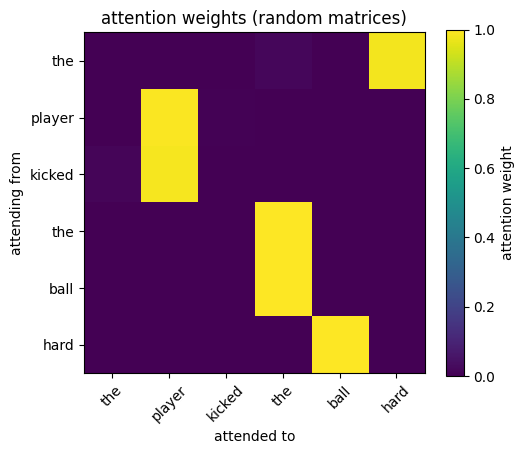

In [17]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(weights.detach(), cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(n), sentence, rotation=45); plt.yticks(range(n), sentence)
plt.xlabel("attended to"); plt.ylabel("attending from")
plt.title("attention weights (random matrices)")
plt.show()

The pattern here means nothing: the three matrices are random. In a real network they are trained by gradient descent like every other weight, and Part 4 shows the result inside a pretrained model.

### 3.1 Why divide by the square root of the dimension
Dot products in higher dimensions are sums of more terms, so scores grow with $d$. Large scores saturate softmax: one token takes nearly all the weight, the rest receive nearly zero, and the gradient almost vanishes, the same saturation problem as in Session 7:

In [18]:
raw_scores = torch.tensor([8.0, 4.0, 2.0])

print("without scaling:", torch.softmax(raw_scores, dim=0).round(decimals=3).tolist())
print("divided by 8:   ", torch.softmax(raw_scores / 8, dim=0).round(decimals=3).tolist())

without scaling: [0.9800000190734863, 0.017999999225139618, 0.0020000000949949026]
divided by 8:    [0.48100000619888306, 0.2919999957084656, 0.22699999809265137]


### 3.2 The causal mask
A model that generates text must not read the future it is predicting. Setting those scores to minus infinity before softmax makes their weights exactly zero:

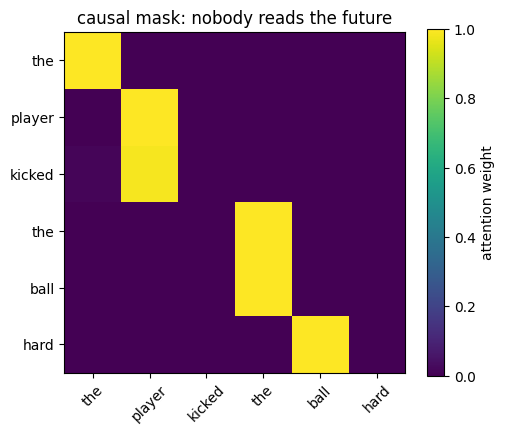

In [19]:
causal_mask = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
_, masked_weights = attention(X, Wq, Wk, Wv, mask=causal_mask)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(masked_weights.detach(), cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(n), sentence, rotation=45); plt.yticks(range(n), sentence)
plt.title("causal mask: nobody reads the future")
plt.show()

The matrix is lower triangular. Models built this way (GPT and relatives) are called decoder-only; models without the mask (BERT and relatives) read the sentence in both directions.

### 3.3 The full layer
A real transformer layer adds three things to the attention above. **Multi-head attention** runs several attentions in parallel on slices of the vector, so with $d_{model} = 512$ and 8 heads each head works in 64 dimensions and their outputs are concatenated back to 512. **Residual connections** add the input back to the output, exactly as in the ResNet of Session 8. **Layer normalization** keeps activations in a stable range:

In [20]:
from torch import nn

class TransformerLayer(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, heads, batch_first=True)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.ReLU(), nn.Linear(4 * d_model, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attention(h, h, h, need_weights=False)[0]     # tokens talk to each other
        return x + self.feed_forward(self.norm2(x))                # each token thinks alone

layer = TransformerLayer(d_model=512, heads=8)
print("parameters in one layer:", sum(p.numel() for p in layer.parameters()))

dummy = torch.randn(1, 10, 512)          # batch of 1, sentence of 10 tokens
print("input:", tuple(dummy.shape), "-> output:", tuple(layer(dummy).shape))

parameters in one layer: 3152384


input: (1, 10, 512) -> output: (1, 10, 512)


About 3.15 million parameters, and the output shape equals the input shape, which is why layers stack directly: 12 of them in GPT-2 small, 96 in GPT-3.

### 3.4 Position has to be added
Attention treats its input as a set. Reorder the tokens and the same weights are computed on the same pairs, so "Ali gave Sara a book" and "Sara gave Ali a book" would be identical. The fix is to add a **position vector** to each token before the first layer, classically sine waves of different frequencies:

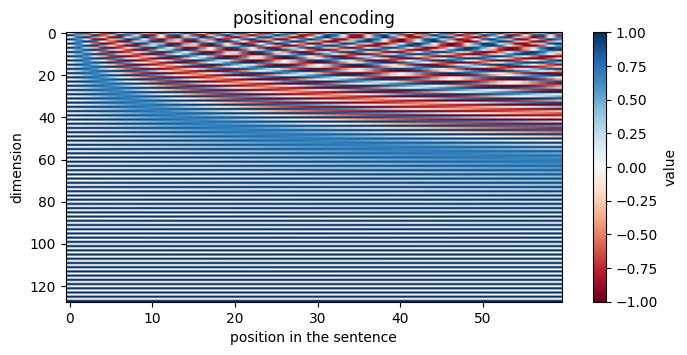

In [21]:
def positional_encoding(length, d_model):
    pos = torch.arange(length).unsqueeze(1)
    i = torch.arange(0, d_model, 2)
    angle = pos / (10000 ** (i / d_model))
    pe = torch.zeros(length, d_model)
    pe[:, 0::2] = torch.sin(angle)
    pe[:, 1::2] = torch.cos(angle)
    return pe

plt.figure(figsize=(8, 3.5))
plt.imshow(positional_encoding(60, 128).T, cmap="RdBu", aspect="auto")
plt.colorbar(label="value")
plt.xlabel("position in the sentence"); plt.ylabel("dimension")
plt.title("positional encoding")
plt.show()

Each position gets a unique pattern of waves, like clock hands turning at different speeds, so attention can tell "first word" from "fifth word".

### ✏️ Exercise 6
Check the budget property numerically: confirm with `torch.allclose` that every row of `weights` sums to 1, and that every row of `masked_weights` does too, even though many of its entries are zero. Print row 2 of the masked weights to see how the budget is redistributed.

In [22]:
# ✏️ your check



<details>
<summary>💡 Solution (click to open)</summary>

```python
ones = torch.ones(n)
print(torch.allclose(weights.sum(dim=-1), ones, atol=1e-5))
print(torch.allclose(masked_weights.sum(dim=-1), ones, atol=1e-5))
print(masked_weights[2].round(decimals=3).tolist())
```

Both hold. Masking does not remove the budget, it redistributes it: row 2 spreads its full 1.0 over the first three positions and gives exactly zero to the rest.

</details>

### ✏️ Exercise 7
Remove the scaling: compute the weights with `Q @ K.transpose(-2, -1)` and no division, then compare the maximum weight per row against the scaled version. How much sharper does the unscaled softmax get?

In [23]:
# ✏️ unscaled attention



<details>
<summary>💡 Solution (click to open)</summary>

```python
Q, K = X @ Wq, X @ Wk
unscaled = torch.softmax(Q @ K.transpose(-2, -1), dim=-1)

print("scaled max per row:  ", weights.max(dim=-1).values.round(decimals=2).tolist())
print("unscaled max per row:", unscaled.max(dim=-1).values.round(decimals=2).tolist())
```

Unscaled rows put almost all their weight on one token, close to 1.00. A saturated softmax passes almost no gradient, so the layer would barely learn, which is exactly why the square root of $d$ appears in the formula.

</details>

### ✏️ Exercise 8
Build the causal mask without `torch.triu`: create an `n` by `n` boolean tensor whose entry `[i, j]` is `True` when `j > i`, and confirm it equals `causal_mask`.

In [24]:
# ✏️ your mask



<details>
<summary>💡 Solution (click to open)</summary>

```python
rows = torch.arange(n).unsqueeze(1)
cols = torch.arange(n).unsqueeze(0)
print(torch.equal(cols > rows, causal_mask))
```

The mask is just the comparison "is this position in the future". Causality in a language model is a boolean matrix, not a special algorithm.

</details>

### ✏️ Exercise 9
Compute by hand the parameter count of one layer with $d_{model} = 768$ and 12 heads, the BERT-base configuration: three matrices $Q$, $K$, $V$ of size $d \times d$, one output matrix $d \times d$, and a feed-forward pair $d \times 4d$ and $4d \times d$. Then verify with `TransformerLayer`.

In [25]:
# ✏️ hand computation, then the check



<details>
<summary>💡 Solution (click to open)</summary>

```python
d = 768
by_hand = 4 * (d * d) + (d * 4 * d) + (4 * d * d)
print("weights only, by hand:", by_hand)
print("actual:", sum(p.numel() for p in TransformerLayer(768, 12).parameters()))
```

About 7.08 million weights by hand and roughly 7.09 million in total, the difference being biases and the two normalization layers. Twelve of these layers give the 85 million transformer parameters of BERT-base.

</details>

### ✏️ Exercise 10
Show that attention is order-blind without positional encoding: build a small `X` of 4 token vectors, compute attention, then reverse the token order and compute again. Compare the outputs after undoing the reversal.

In [26]:
# ✏️ order test



<details>
<summary>💡 Solution (click to open)</summary>

```python
Xs = torch.randn(4, 16)
Wq4, Wk4, Wv4 = torch.randn(16, 16), torch.randn(16, 16), torch.randn(16, 16)

out_a, _ = attention(Xs, Wq4, Wk4, Wv4)
out_b, _ = attention(Xs.flip(0), Wq4, Wk4, Wv4)
print(torch.allclose(out_a, out_b.flip(0), atol=1e-5))
```

`True`: reversing the input merely reverses the output, so every token computed exactly what it computed before. Order information has to be injected separately, which is what the positional encoding does.

</details>

---
# Part 4: Using a real pretrained transformer

The same machinery, trained on billions of words and downloadable in three lines. We use BERT, an encoder-only transformer (no causal mask, so every token reads the whole sentence). The `USE_TF` line keeps `transformers` on PyTorch, consistent with the rest of the course:

In [27]:
import os
os.environ["USE_TF"] = "0"

from transformers import AutoTokenizer, AutoModel

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name).eval()

print("parameters:", sum(p.numel() for p in bert.parameters()))
print("vocabulary size:", tokenizer.vocab_size)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


parameters: 109482240
vocabulary size: 30522


### 4.1 Subword tokens
Real systems do not use whole words. The vocabulary is a fixed inventory of about 30,000 **subword** pieces, so common words are single tokens, rare words decompose, and nothing is ever out of vocabulary:

In [28]:
for text in ["the player kicked the ball", "unbelievable", "zorgomatic"]:
    print(f"{text!r} -> {tokenizer.tokenize(text)}")

'the player kicked the ball' -> ['the', 'player', 'kicked', 'the', 'ball']
'unbelievable' -> ['unbelievable']
'zorgomatic' -> ['z', '##org', '##oma', '##tic']


### 4.2 Contextual vectors resolve ambiguity
This is the payoff. Part 2 ended on `bank` having one averaged vector. Here the model computes a vector for that token **in each sentence**, so we can measure whether the two senses separate. Three sentences, two with the river sense and one with the financial sense:

In [29]:
sentences = ["he sat on the river bank",
             "the boat reached the muddy river bank",
             "he went to the bank to deposit money"]

token_vectors = []
for s in sentences:
    encoded = tokenizer(s, return_tensors="pt")
    pieces = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    with torch.no_grad():
        hidden = bert(**encoded).last_hidden_state[0]
    token_vectors.append(hidden[pieces.index("bank")])

V = torch.stack(token_vectors)
V = V / V.norm(dim=1, keepdim=True)
similarity = (V @ V.T).numpy()

for i, s in enumerate(sentences):
    print(i, "=", s)
print(np.round(similarity, 2))

0 = he sat on the river bank
1 = the boat reached the muddy river bank
2 = he went to the bank to deposit money
[[1.   0.8  0.32]
 [0.8  1.   0.25]
 [0.32 0.25 1.  ]]


The two river sentences score about 0.80 with each other, while river against money scores about 0.32. The same input word produced **different vectors**, positioned by the words around it. A static table could never do this; attention is what makes it possible, because after each layer a token's vector is a weighted mixture of its neighbours.

### 4.3 The model's own attention
The weights inside the pretrained model are extractable, and they are the same object built in Part 3:

layers: 12 | heads per layer: 12


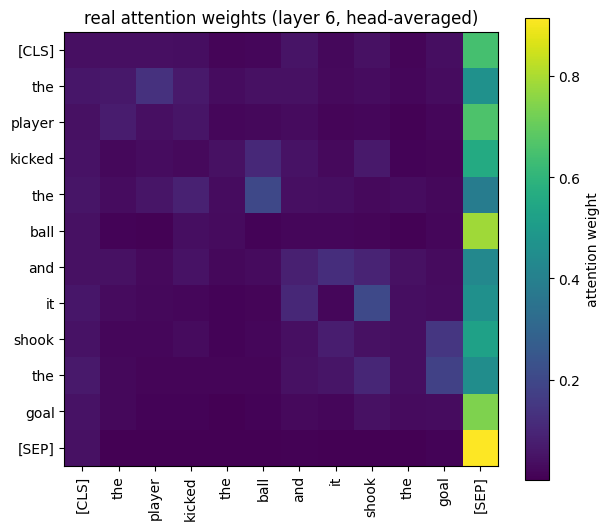

In [30]:
encoded = tokenizer("the player kicked the ball and it shook the goal", return_tensors="pt")
pieces = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
with torch.no_grad():
    outputs = bert(**encoded, output_attentions=True)

print("layers:", len(outputs.attentions), "| heads per layer:", outputs.attentions[0].shape[1])

attention_map = outputs.attentions[5][0].mean(dim=0)      # layer 6, averaged over heads

plt.figure(figsize=(7, 6))
plt.imshow(attention_map, cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(len(pieces)), pieces, rotation=90); plt.yticks(range(len(pieces)), pieces)
plt.title("real attention weights (layer 6, head-averaged)")
plt.show()

Not lower triangular, because BERT reads in both directions. Individual heads specialize, some tracking adjacent words and others syntactic relations, and many resist interpretation entirely, exactly like the CNN filters of Session 8.

### 4.4 Ready-made models
For most applications nothing needs to be built at all. A model with a classification head fine-tuned on labeled reviews is three lines away, and this is the transfer-learning recipe of Session 8 applied to language:

In [31]:
from transformers import AutoModelForSequenceClassification

sentiment_name = "distilbert-base-uncased-finetuned-sst-2-english"
sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_name).eval()

for text in ["this movie was really great", "the quality was awful and I was not satisfied"]:
    with torch.no_grad():
        probs = sentiment_model(**sentiment_tokenizer(text, return_tensors="pt")).logits.softmax(dim=-1)[0]
    label = sentiment_model.config.id2label[int(probs.argmax())]
    print(f"{text!r} -> {label} ({probs.max():.2f})")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


'this movie was really great' -> POSITIVE (1.00)
'the quality was awful and I was not satisfied' -> NEGATIVE (1.00)


### ✏️ Exercise 11
Test the contextual claim on a word of your own. Pick an ambiguous English word (`bat`, `spring`, `light`, `match`), write two sentences with the same sense and one with a different sense, and check that the same-sense pair scores higher.

In [32]:
# ✏️ your three sentences and their similarity matrix



<details>
<summary>💡 Solution (click to open)</summary>

```python
my_sentences = ["the bat flew out of the dark cave",
                "a small bat hung from the ceiling of the cave",
                "he swung the bat and hit the ball"]

vecs = []
for s in my_sentences:
    enc = tokenizer(s, return_tensors="pt")
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    with torch.no_grad():
        h = bert(**enc).last_hidden_state[0]
    vecs.append(h[toks.index("bat")])

Vm = torch.stack(vecs)
Vm = Vm / Vm.norm(dim=1, keepdim=True)
print(np.round((Vm @ Vm.T).numpy(), 2))
```

The two animal sentences land closer to each other than either does to the sports sentence. The effect is reliable but not perfect: short sentences give attention less context to work with.

</details>

### ✏️ Exercise 12
Contextualization is gradual. Extract the `bank` vectors from the **first** layer and from the last (`bert(**enc, output_hidden_states=True).hidden_states[k]`), and compute the similarity matrix for both. In which layer are the senses more separated?

In [33]:
# ✏️ early layer versus late layer



<details>
<summary>💡 Solution (click to open)</summary>

```python
def bank_vectors(layer_index):
    vs = []
    for s in sentences:
        enc = tokenizer(s, return_tensors="pt")
        toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
        with torch.no_grad():
            hs = bert(**enc, output_hidden_states=True).hidden_states
        vs.append(hs[layer_index][0][toks.index("bank")])
    Vx = torch.stack(vs)
    return Vx / Vx.norm(dim=1, keepdim=True)

for layer_index in (1, 12):
    Vx = bank_vectors(layer_index)
    print("layer", layer_index, "\n", np.round((Vx @ Vx.T).numpy(), 2))
```

Early layers keep the three vectors close together, since they are still near the static embedding, and later layers separate the senses. Each layer mixes in a little more of the surrounding sentence.

</details>

### ✏️ Exercise 13
Run the sentiment model on three sentences of your own, including one sarcastic. Where does it fail, and what does that say about reading the confidence number?

In [34]:
# ✏️ your sentences



<details>
<summary>💡 Solution (click to open)</summary>

```python
for text in ["the food was fine I guess",
             "great, another delayed flight",
             "I have never seen anything like this"]:
    with torch.no_grad():
        probs = sentiment_model(**sentiment_tokenizer(text, return_tensors="pt")).logits.softmax(dim=-1)[0]
    label = sentiment_model.config.id2label[int(probs.argmax())]
    print(f"{text!r} -> {label} ({probs.max():.2f})")
```

Sarcasm is the standard failure: "great, another delayed flight" is usually labeled positive with high confidence, because the surface words are positive and sarcastic reviews are rare in the training data. High confidence is not evidence of correctness, a lesson this course has repeated since Session 5.

</details>

---
# Part 5: A Kaggle competition, end to end

Parts 1 to 4 built the ideas. This part is the job: take a real competition, build a solution, measure it honestly, and produce a submission file.

The competition is [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started), the standard entry point for text classification. The task is subtle in exactly the way this session predicts: a tweet containing "ablaze" or "flood" may report an emergency, or may be metaphor, sarcasm, or a song lyric. Bag of words sees the word; only context settles the meaning.

The data loads from Kaggle when the notebook runs there, and from a public mirror otherwise:

In [35]:
import os
import pandas as pd

KAGGLE_PATH = "/kaggle/input/nlp-getting-started"
MIRROR = "https://raw.githubusercontent.com/Satwato/Kaggle-NLP-with-Disaster-Tweets/master"
source = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else MIRROR

train = pd.read_csv(f"{source}/train.csv")
test = pd.read_csv(f"{source}/test.csv")

print("train:", train.shape, "| test:", test.shape)
print("columns:", list(train.columns))
train.head(3)

train: (7613, 5) | test: (3263, 4)
columns: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1


### 5.1 Look at the data first
Session 5's rule applies to text as well: never model before looking.

In [36]:
print("labels:", train["target"].value_counts().to_dict())
print("missing values:", train.isna().sum().to_dict())

for label in (1, 0):
    example = train[train.target == label].iloc[0]["text"]
    print(f"\ntarget={label}: {example}")

labels: {0: 4342, 1: 3271}
missing values: {'id': 0, 'keyword': 61, 'location': 2533, 'text': 0, 'target': 0}

target=1: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

target=0: What's up man?


7,613 labeled tweets, 43% of them real disasters, plus 3,263 unlabeled tweets to predict. Two side columns exist, `keyword` (nearly complete) and `location` (a third missing and full of free text), which the exercises revisit. Distributions:

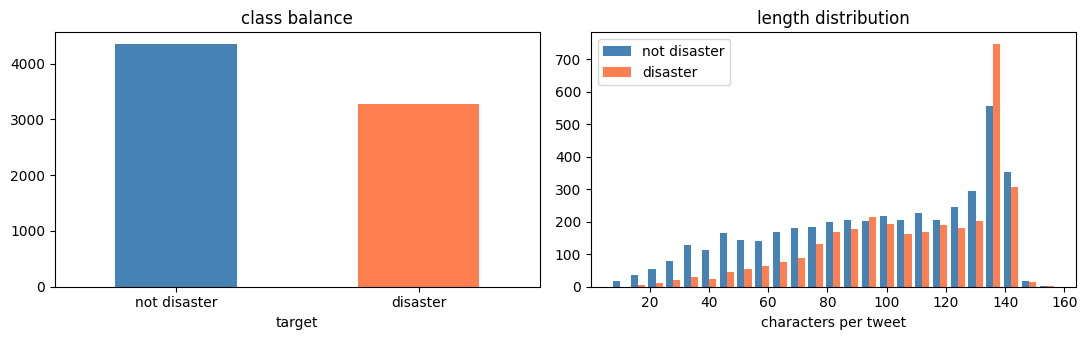

In [37]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
train["target"].value_counts().sort_index().plot(kind="bar", ax=ax1, color=["steelblue", "coral"])
ax1.set_xticklabels(["not disaster", "disaster"], rotation=0); ax1.set_title("class balance")

ax2.hist([train[train.target == 0]["text"].str.len(), train[train.target == 1]["text"].str.len()],
         bins=25, label=["not disaster", "disaster"], color=["steelblue", "coral"])
ax2.set_xlabel("characters per tweet"); ax2.legend(); ax2.set_title("length distribution")
plt.tight_layout(); plt.show()

The classes are close to balanced and the lengths overlap almost completely, so length carries no signal. The words have to do the work.

### 5.2 The metric: F1, not accuracy
The competition scores submissions with the **F1 score** on the disaster class, the harmonic mean of precision and recall:

$$\text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}, \qquad F_1 = 2\,\frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

Precision asks how many flagged tweets were truly disasters; recall asks how many real disasters were caught. Accuracy would let a model win by ignoring the minority class, and for an emergency-response tool that is the wrong incentive, and F1 forces a model to be good at both.

### 5.3 Solution 1: the bag-of-words baseline
Start with the classic bag-of-words baseline. **TF-IDF** turns each tweet into a vector of weighted word counts, where the weight of a word is its count in the tweet times the logarithm of how rare it is across tweets:

$$\\text{tfidf}(w, d) = \\text{count}(w, d) \\times \\log\\frac{N}{\\text{df}(w)}$$

so words appearing everywhere (like "the") get almost no weight. The classifier on top is `LogisticRegression`, which is exactly the sigmoid neuron of Session 7 with thousands of word columns as input. A baseline exists to be beaten, and to reveal how much of the problem is easy:

In [38]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

text_train, text_val, y_train_k, y_val_k = train_test_split(
    train["text"], train["target"], test_size=0.2, random_state=42, stratify=train["target"])

tfidf_model = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
tfidf_model.fit(text_train, y_train_k)
pred_tfidf = tfidf_model.predict(text_val)

print("F1:       ", round(f1_score(y_val_k, pred_tfidf), 3))
print("precision:", round(precision_score(y_val_k, pred_tfidf), 3))
print("recall:   ", round(recall_score(y_val_k, pred_tfidf), 3))
print("accuracy: ", round((pred_tfidf == y_val_k).mean(), 3))

F1:        0.764
precision: 0.803
recall:    0.729
accuracy:  0.807


F1 of 0.764, with precision above recall: the model is cautious, missing real disasters rather than raising false alarms. The confusion matrix shows where the errors sit:

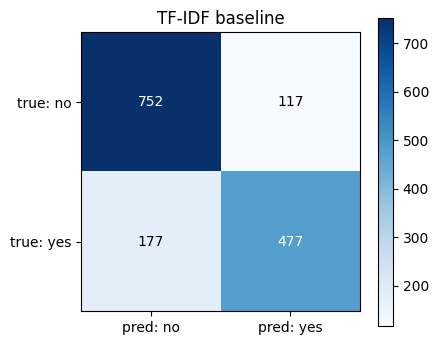

In [39]:
cm = confusion_matrix(y_val_k, pred_tfidf)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.xticks([0, 1], ["pred: no", "pred: yes"]); plt.yticks([0, 1], ["true: no", "true: yes"])
plt.title("TF-IDF baseline")
plt.colorbar(); plt.show()

### 5.4 Validating honestly
One split is one sample of luck. Cross-validation averages it away, but this dataset hides a trap: the rows are **ordered by keyword**, so contiguous folds are not representative. The fix is stratified folds with shuffling, which is what the exercise makes concrete:

In [40]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)),
                         train["text"], train["target"], cv=folds, scoring="f1")

print("fold scores:", scores.round(3).tolist())
print("mean F1:", round(scores.mean(), 3), "+-", round(scores.std(), 3))

fold scores: [0.763, 0.751, 0.737, 0.75, 0.755]
mean F1: 0.751 +- 0.009


0.751 with a standard deviation under 0.01, a number worth trusting. Any change from here on is judged against it.

### 5.5 Error analysis
The mistakes say what the model cannot see:

In [41]:
import numpy as np

wrong = np.where(pred_tfidf != y_val_k.values)[0][:6]
for i in wrong:
    print(f"true={y_val_k.values[i]}  pred={pred_tfidf[i]}  |  {text_val.values[i][:95]}")

true=0  pred=1  |  @TheEconomist Step one: get that mass murderer's portrait off the yuan.
true=1  pred=0  |  Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped 
true=1  pred=0  |  I can't drown my demons they know how to swim
true=1  pred=0  |  @XHNews We need these plants in the pacific during the cyclone seasons it would help
true=0  pred=1  |  if firefighters acted like cops they'd drive around shooting a flamethrower at burning building
true=1  pred=0  |  'It looks like a mudslide' poor thing! ?? #greatbritishbakeoff


Read them one by one. "I can't drown my demons they know how to swim" contains drowning and is labeled a disaster in the data, though a human reader hears a metaphor: some labels in this competition are genuinely debatable, which caps what any model can reach. Others are honest failures of bag of words: a film about trapped miners, a comparison involving firefighters. The word is present, the meaning is not. This is the exact gap Parts 3 and 4 built the machinery to close.

### 5.6 Solution 2: frozen transformer features
The Session 8 move applied to text: run every tweet through a pretrained transformer, keep the vectors, and train a linear classifier on them. No weight of the transformer is updated, so this is fast even on a CPU. Each tweet becomes one 768-dimensional vector by averaging its token vectors:

In [42]:
import torch
from transformers import AutoTokenizer, AutoModel

encoder_name = "distilbert-base-uncased"
encoder_tokenizer = AutoTokenizer.from_pretrained(encoder_name)
encoder = AutoModel.from_pretrained(encoder_name).eval()

def embed(texts, batch_size=64):
    vectors = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = encoder_tokenizer(list(texts[i:i + batch_size]), padding=True,
                                      truncation=True, max_length=48, return_tensors="pt")
            hidden = encoder(**batch).last_hidden_state
            mask = batch["attention_mask"].unsqueeze(-1)
            vectors.append((hidden * mask).sum(dim=1) / mask.sum(dim=1))   # mean pooling
    return torch.cat(vectors).numpy()

features_train = embed(text_train.tolist())
features_val = embed(text_val.tolist())
print("feature matrix:", features_train.shape)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


feature matrix: (6090, 768)


In [43]:
probe = LogisticRegression(max_iter=2000).fit(features_train, y_train_k)
pred_probe = probe.predict(features_val)

print("F1:       ", round(f1_score(y_val_k, pred_probe), 3))
print("precision:", round(precision_score(y_val_k, pred_probe), 3))
print("recall:   ", round(recall_score(y_val_k, pred_probe), 3))

F1:        0.796
precision: 0.832
recall:    0.763


0.796 against 0.764, with no training of the language model at all. The gain comes from the representation: contextual vectors already encode that a burning building differs from a burning question.

### 5.7 Solution 3: fine-tuning
Now update the whole model on this task, the text counterpart of the fine-tuning in Session 8. Two epochs take about four minutes on a CPU and well under a minute on a Colab GPU:

In [44]:
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification

def make_loader(texts, labels, batch_size, shuffle):
    batch = encoder_tokenizer(list(texts), padding="max_length", truncation=True,
                              max_length=48, return_tensors="pt")
    dataset = TensorDataset(batch["input_ids"], batch["attention_mask"], torch.tensor(list(labels)))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

torch.manual_seed(42)
classifier = AutoModelForSequenceClassification.from_pretrained(encoder_name, num_labels=2)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=2e-5)

train_loader = make_loader(text_train, y_train_k, 32, True)
val_loader = make_loader(text_val, y_val_k, 64, False)

for epoch in range(2):
    classifier.train()
    total = 0.0
    for input_ids, mask, labels in train_loader:
        out = classifier(input_ids=input_ids, attention_mask=mask, labels=labels)
        out.loss.backward(); optimizer.step(); optimizer.zero_grad()
        total += out.loss.item() * len(labels)
    print(f"epoch {epoch + 1} | mean loss {total / len(text_train):.3f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1 | mean loss 0.451


epoch 2 | mean loss 0.338


In [45]:
classifier.eval()
predictions = []
with torch.no_grad():
    for input_ids, mask, labels in val_loader:
        predictions.append(classifier(input_ids=input_ids, attention_mask=mask).logits.argmax(dim=1))
pred_finetuned = torch.cat(predictions).numpy()

print("F1:       ", round(f1_score(y_val_k, pred_finetuned), 3))
print("precision:", round(precision_score(y_val_k, pred_finetuned), 3))
print("recall:   ", round(recall_score(y_val_k, pred_finetuned), 3))

F1:        0.817
precision: 0.859
recall:    0.78


### 5.8 The scoreboard and the submission
| solution | what was trained | validation F1 |
|---|---|---|
| TF-IDF plus logistic regression | a linear model over word counts | 0.764 |
| frozen transformer features plus linear model | the linear model only | 0.796 |
| fine-tuned DistilBERT | all 66 million parameters | 0.817 |

The ordering matches the vision session exactly: counting, then pretrained features, then fine-tuning. Public leaderboard scores above roughly 0.85 come from looking up the original tweets, so an honest 0.80 is a solid result here.

The last step of any competition is the submission file: predictions for `test.csv`, with the exact column names the organizers expect:

In [46]:
test_loader = make_loader(test["text"], [0] * len(test), 64, False)

test_predictions = []
with torch.no_grad():
    for input_ids, mask, _ in test_loader:
        test_predictions.append(classifier(input_ids=input_ids, attention_mask=mask).logits.argmax(dim=1))
test_predictions = torch.cat(test_predictions).numpy()

submission = pd.DataFrame({"id": test["id"], "target": test_predictions})
submission.to_csv("submission.csv", index=False)

print("rows:", len(submission), "| predicted disaster rate:", round(test_predictions.mean(), 3))
submission.head()

rows: 3263 | predicted disaster rate: 0.371


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


`submission.csv` is now on disk, and uploading it to the competition page returns a leaderboard score within minutes. On Kaggle the file appears in the notebook output; locally it sits next to this notebook.

### ✏️ Exercise 14
The classifier decides at probability 0.5, which is not necessarily the best threshold for F1. Using `tfidf_model.predict_proba(text_val)[:, 1]`, compute the F1 at thresholds from 0.2 to 0.8 in steps of 0.05 and report the best one.

In [47]:
# ✏️ threshold sweep



<details>
<summary>💡 Solution (click to open)</summary>

```python
probabilities = tfidf_model.predict_proba(text_val)[:, 1]
for threshold in np.arange(0.2, 0.81, 0.05):
    score = f1_score(y_val_k, (probabilities > threshold).astype(int))
    print(f"threshold {threshold:.2f} -> F1 {score:.3f}")
```

The maximum sits near 0.45 to 0.50, so the default is already close to optimal here. On imbalanced problems the gap is often large, and threshold tuning is one of the cheapest ways to gain leaderboard positions, since it costs no training at all.

</details>

### ✏️ Exercise 15
The `keyword` column is nearly complete and clearly relevant. Prepend it to the tweet text (`train["keyword"].fillna("none")` plus a space plus the text), retrain the TF-IDF baseline, and measure the change in validation F1.

In [48]:
# ✏️ keyword as an extra signal



<details>
<summary>💡 Solution (click to open)</summary>

```python
combined_train = X_kw_train = train.loc[text_train.index, "keyword"].fillna("none") + " " + text_train
combined_val = train.loc[text_val.index, "keyword"].fillna("none") + " " + text_val

model_kw = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
model_kw.fit(combined_train, y_train_k)
print("with keyword:", round(f1_score(y_val_k, model_kw.predict(combined_val)), 3))
```

About 0.767 against 0.764: a real but small gain, because the keyword is usually present in the tweet already. Feature engineering on text pays off less than on tabular data (Session 6), since the text already contains most of the signal.

</details>

### ✏️ Exercise 16
Reproduce the validation trap of 5.4: run `cross_val_score` with plain `cv=5` instead of the shuffled stratified folds, and compare the fold scores. Then look at `train["keyword"].head(20)` and explain what went wrong.

In [49]:
# ✏️ the unshuffled folds



<details>
<summary>💡 Solution (click to open)</summary>

```python
plain = cross_val_score(make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000)),
                        train["text"], train["target"], cv=5, scoring="f1")
print("plain folds:", plain.round(3).tolist(), "mean", round(plain.mean(), 3))
print(train["keyword"].head(20).tolist())
```

The plain folds scatter from about 0.61 to 0.75 and average roughly 0.10 below the shuffled estimate. The reason is in the file: the rows are grouped by keyword, with the missing-keyword rows first, so each contiguous fold sees a different slice of topics and is trained on the rest. Whenever data arrives sorted by anything, shuffle before splitting.

</details>

### ✏️ Exercise 17
Run the error analysis of 5.5 on the fine-tuned model instead: print the tweets it still gets wrong. Do they overlap with the baseline's mistakes, and are the remaining errors genuinely ambiguous?

In [50]:
# ✏️ errors of the fine-tuned model



<details>
<summary>💡 Solution (click to open)</summary>

```python
wrong_ft = np.where(pred_finetuned != y_val_k.values)[0][:8]
for i in wrong_ft:
    print(f"true={y_val_k.values[i]}  pred={pred_finetuned[i]}  |  {text_val.values[i][:95]}")

overlap = set(wrong_ft) & set(np.where(pred_tfidf != y_val_k.values)[0])
print("\nshared with the baseline:", len(overlap), "of", len(wrong_ft))
```

Many of the remaining errors are cases where two readers would disagree, plus a share of debatable labels. That is the practical meaning of a performance ceiling: beyond a point, the limit is the data, not the model, which is the same lesson the Titanic session taught with its 0.84 ceiling.

</details>

---
# Part 6: Summary and next steps

The session in one table:

| representation | what a word is | strength | weakness |
|---|---|---|---|
| one-hot | an independent column | trivial to build | huge, and no similarity at all |
| pretrained embedding | a learned dense vector | similar meanings sit close, arithmetic works | one vector per word, context ignored |
| contextual (transformer) | a vector computed per sentence | ambiguity resolved by the neighbours | costly, quadratic in sequence length |

The mechanism behind the last row, built here from scratch: three learnable matrices produce queries, keys and values; scaled dot products become weights through softmax; each token's output is a weighted mixture of the whole sentence. Add multiple heads, residual connections, normalization and positional encoding, and that is a transformer layer. Stacking it is the entire architecture behind modern language models.

Part 5 then put all of it to work on a real competition, where the same ladder appeared once more: word counts 0.764, frozen transformer features 0.796, fine-tuned model 0.817, with the remaining errors sitting on genuinely ambiguous tweets.

Next session takes this architecture, scales it to billions of parameters, and examines what emerges: the language model itself.

### ✏️ Exercise 18: homework
1. Submit the `submission.csv` of Part 5 to the [competition page](https://www.kaggle.com/competitions/nlp-getting-started) and compare your leaderboard score with the validation F1. Then improve it: more epochs, a larger pretrained model, the keyword column, or an ensemble of the three solutions.
2. Repeat the Part 2 exploration with your own word list. Which relations does the space capture well (countries, plurals, comparatives) and which does it miss?
3. Read [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) with this notebook open beside it, and match each figure in the article to the code you ran in Part 3.